# Task 2.2 Supervised preprocessing and visualization

by Sneha Sivakaran Modul 12

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

In [2]:
# 1. Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/diabetes.csv')

#Consider the meaning of zeros before removal
cols_with_zeros = ['plas', 'pres', 'skin', 'insu', 'mass']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

In [3]:
# 2. Define and apply IQR-based outlier detection

# Select only numerical feature columns (exclude target variable)
numeric_cols = df.select_dtypes(include=[np.number]).columns

if 'class' in numeric_cols:
    numeric_cols = numeric_cols.drop('class')
elif 'Outcome' in numeric_cols:
    numeric_cols = numeric_cols.drop('Outcome')

# Compute quartiles and IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Set limits for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [4]:
# 3. Replace outliers with NA and select complete cases
outlier_mask = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound))
# Replaces all values to which the mask applies with NaN (np.nan)
df[numeric_cols] = df[numeric_cols].mask(outlier_mask, np.nan)

# dropna() removes all rows containing NaNs
df_clean = df.dropna()

In [5]:
# 4. [Optional] Describe single features
print("--- Summary Statistics ---")
print(df_clean.describe())

--- Summary Statistics ---
             preg        plas        pres        skin        insu        mass  \
count  338.000000  338.000000  338.000000  338.000000  338.000000  338.000000   
mean     3.213018  119.784024   70.639053   28.417160  132.949704   32.397929   
std      3.018569   29.274980   11.016304   10.190206   74.329688    6.318915   
min      0.000000   56.000000   44.000000    7.000000   15.000000   18.200000   
25%      1.000000   98.250000   62.500000   20.000000   75.250000   27.825000   
50%      2.000000  116.500000   70.000000   28.500000  120.000000   32.850000   
75%      5.000000  139.000000   78.000000   36.000000  176.000000   36.500000   
max     13.000000  198.000000  102.000000   52.000000  360.000000   49.700000   

             pedi         age  
count  338.000000  338.000000  
mean     0.474574   30.337278  
std      0.251831    9.581379  
min      0.085000   21.000000  
25%      0.268000   23.000000  
50%      0.432000   27.000000  
75%      0.646750  

In [6]:
# 5. Rank features using mutual information
X = df_clean.drop('class', axis=1)
y = df_clean['class']

mi_scores = mutual_info_classif(X, y, random_state=42)
# Convert to a sorted Pandas series
feature_ranking = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
print("\n--- Feature Ranking (Mutual Information) ---")
print(feature_ranking)

# Extract the strongest and weakest features
highest_ranked = feature_ranking.index[0]
lowest_ranked = feature_ranking.index[-1]
print(f"\nHighest ranked feature: {highest_ranked}")
print(f"Lowest ranked feature: {lowest_ranked}")


--- Feature Ranking (Mutual Information) ---
plas    0.136942
age     0.086936
insu    0.080443
mass    0.046317
pres    0.020113
preg    0.017554
skin    0.000000
pedi    0.000000
dtype: float64

Highest ranked feature: plas
Lowest ranked feature: pedi


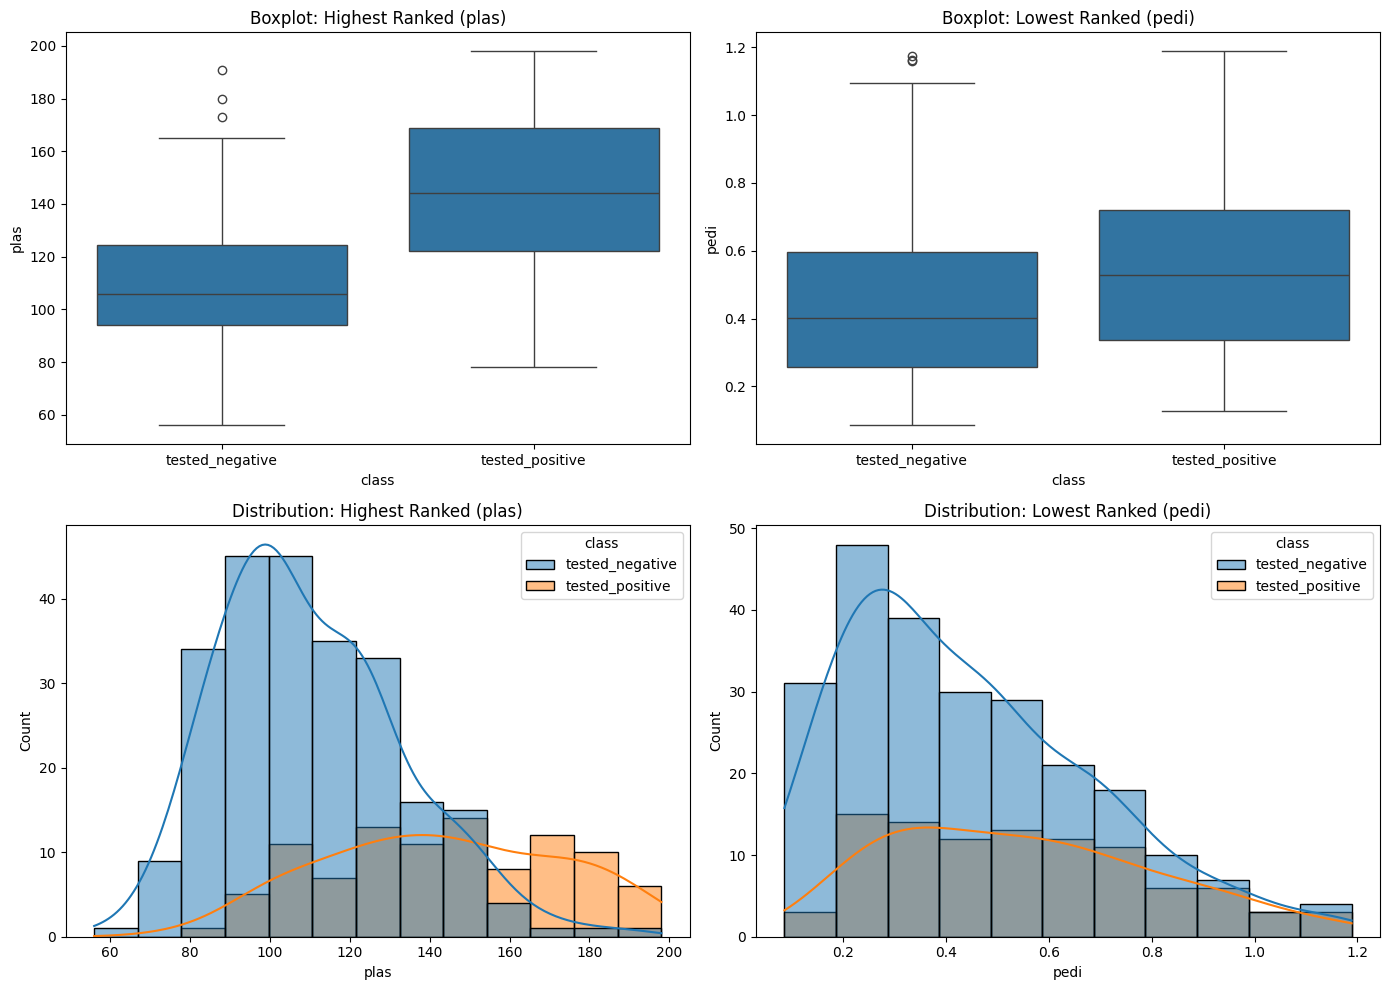

In [7]:
# 6. Create boxplot and distribution plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Boxplots
sns.boxplot(x='class', y=highest_ranked, data=df_clean, ax=axes[0, 0])
axes[0, 0].set_title(f'Boxplot: Highest Ranked ({highest_ranked})')

sns.boxplot(x='class', y=lowest_ranked, data=df_clean, ax=axes[0, 1])
axes[0, 1].set_title(f'Boxplot: Lowest Ranked ({lowest_ranked})')

# Distribution plots
sns.histplot(data=df_clean, x=highest_ranked, hue='class', kde=True, ax=axes[1, 0])
axes[1, 0].set_title(f'Distribution: Highest Ranked ({highest_ranked})')

sns.histplot(data=df_clean, x=lowest_ranked, hue='class', kde=True, ax=axes[1, 1])
axes[1, 1].set_title(f'Distribution: Lowest Ranked ({lowest_ranked})')

plt.tight_layout()
plt.show()